<a href="https://colab.research.google.com/github/sadhaaa/sadhapaEDA/blob/main/EDA_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Load the dataset
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bank_marketing_test.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())
print(df.info())

(8237, 21)
   age          job  marital    education  default housing loan    contact  \
0   56     services  married  high.school       no      no  yes  telephone   
1   41  blue-collar  married      unknown  unknown      no   no  telephone   
2   25     services   single  high.school       no     yes   no  telephone   
3   35  blue-collar  married     basic.6y       no     yes   no  telephone   
4   46  blue-collar  married     basic.6y  unknown     yes  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx 

In [3]:
# 2.Basic statistical analysis
print(df.describe())
print(df.describe(include="object"))
print(df.dtypes.value_counts())

               age     duration    campaign        pdays     previous  \
count  8237.000000  8237.000000  8237.00000  8237.000000  8237.000000   
mean     40.116547   256.007648     2.60471   962.228724     0.174335   
std      10.465328   259.728737     2.91562   187.533881     0.500565   
min      17.000000     4.000000     1.00000     0.000000     0.000000   
25%      32.000000   101.000000     1.00000   999.000000     0.000000   
50%      38.000000   179.000000     2.00000   999.000000     0.000000   
75%      47.000000   316.000000     3.00000   999.000000     0.000000   
max      89.000000  4918.000000    43.00000   999.000000     6.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx    euribor3m  nr.employed  
count   8237.000000     8237.000000    8237.000000  8237.000000  8237.000000  
mean       0.070147       93.577806     -40.545320     3.608206  5166.589790  
std        1.574685        0.582138       4.623626     1.735931    72.470977  
min       -3.400000       

In [5]:
# 3. Handling missing data
df = df.replace(["unknown", "nonexistent"], np.nan)
print(df.isnull().sum())
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [6]:
# 4. Data cleaning
print(df.duplicated().sum())
df = df.drop_duplicates()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.lower()
    df = df.reset_index(drop=True)

2


In [7]:
# 5. Data transformation
df.columns = df.columns.str.replace(".", "_", regex=False)
df["y_flag"] = df["y"].map({"yes": 1, "no": 0})
bins = [17, 30, 40, 50, 60, 100]
labels = ["18-30", "31-40", "41-50", "51-60", "60+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
print(df.head())

   age          job  marital          education default housing loan  \
0   56     services  married        high.school      no      no  yes   
1   41  blue-collar  married  university.degree      no      no   no   
2   25     services   single        high.school      no     yes   no   
3   35  blue-collar  married           basic.6y      no     yes   no   
4   46  blue-collar  married           basic.6y      no     yes  yes   

     contact month day_of_week  ...  previous  poutcome  emp_var_rate  \
0  telephone   may         mon  ...         0   failure           1.1   
1  telephone   may         mon  ...         0   failure           1.1   
2  telephone   may         mon  ...         0   failure           1.1   
3  telephone   may         mon  ...         0   failure           1.1   
4  telephone   may         mon  ...         0   failure           1.1   

   cons_price_idx cons_conf_idx  euribor3m  nr_employed   y  y_flag  age_group  
0          93.994         -36.4      4.857     

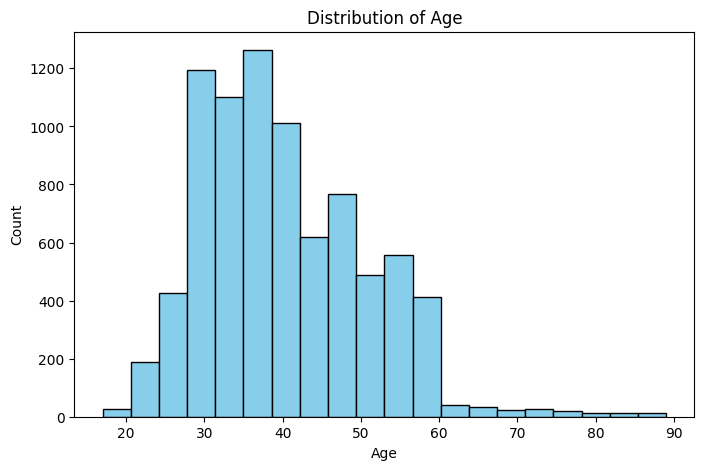

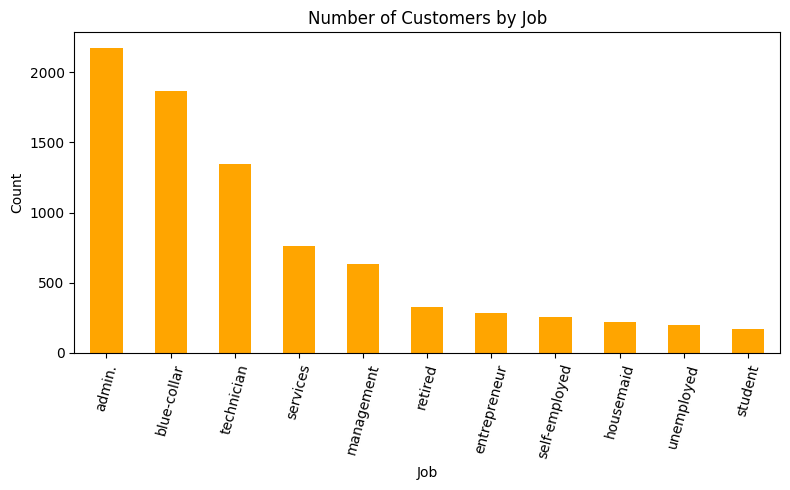

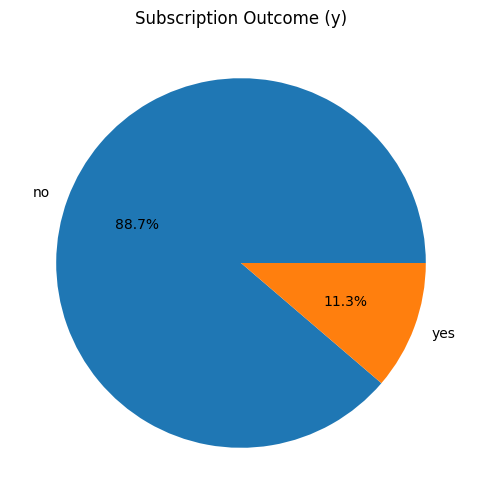

In [12]:
# 6. Univariate analysis
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
df["job"].value_counts().plot(kind="bar", color="orange")
print("\n")
plt.title("Number of Customers by Job")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
df["y"].value_counts().plot(kind="pie", autopct="%1.1f%%")
print("\n")
plt.title("Subscription Outcome (y)")
plt.ylabel("")
plt.show()

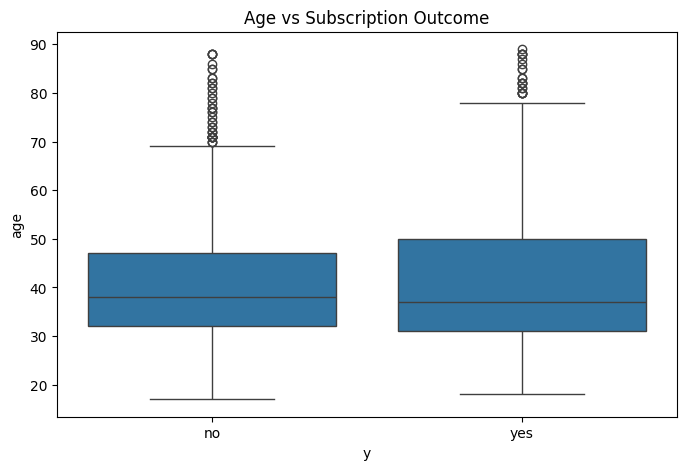

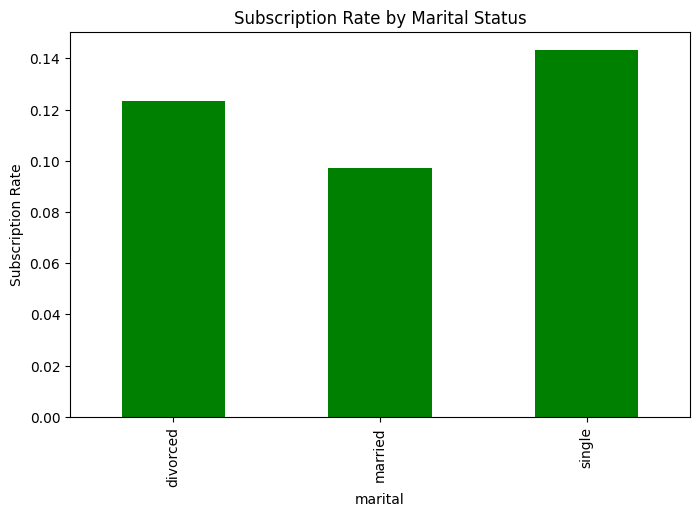

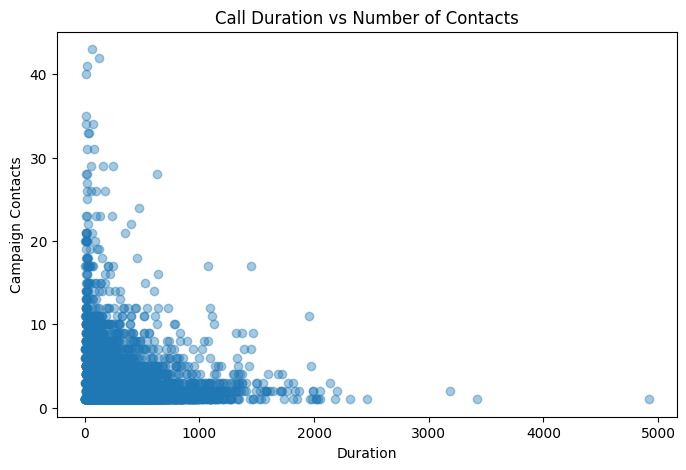

In [13]:
# 7. Bivariate analysis
plt.figure(figsize=(8, 5))
sns.boxplot(x="y", y="age", data=df)
plt.title("Age vs Subscription Outcome")
plt.show()

plt.figure(figsize=(8, 5))
df.groupby("marital")["y_flag"].mean().plot(kind="bar", color="green")
print("\n")
plt.title("Subscription Rate by Marital Status")
plt.ylabel("Subscription Rate")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["duration"], df["campaign"], alpha=0.4)
print("\n")
plt.title("Call Duration vs Number of Contacts")
plt.xlabel("Duration")
plt.ylabel("Campaign Contacts")
plt.show()

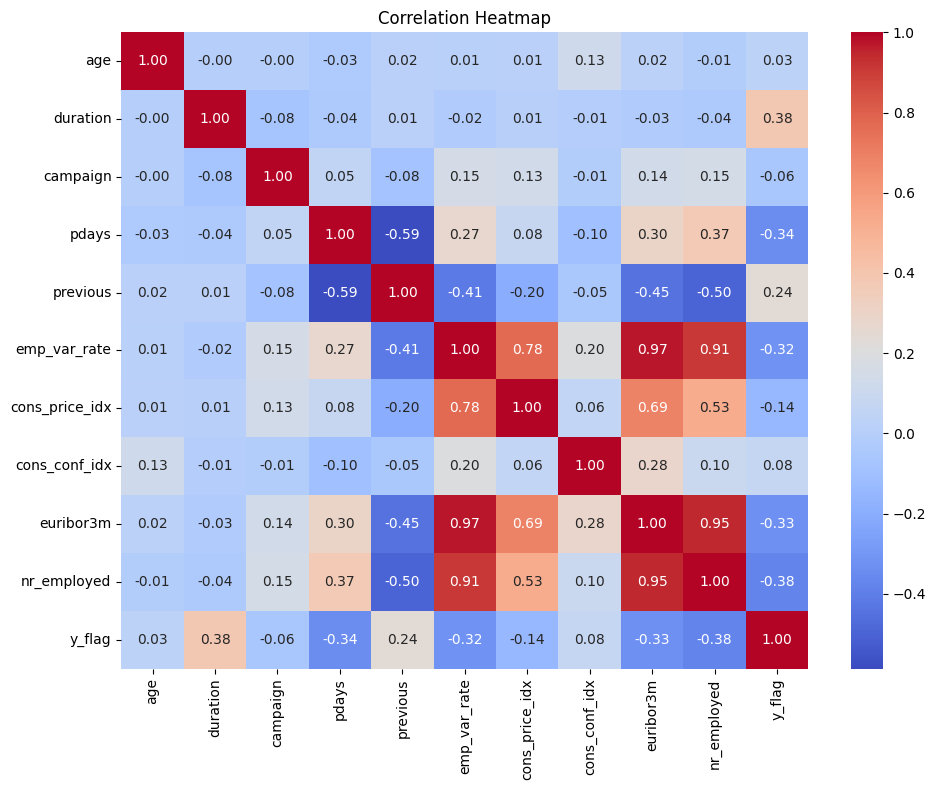

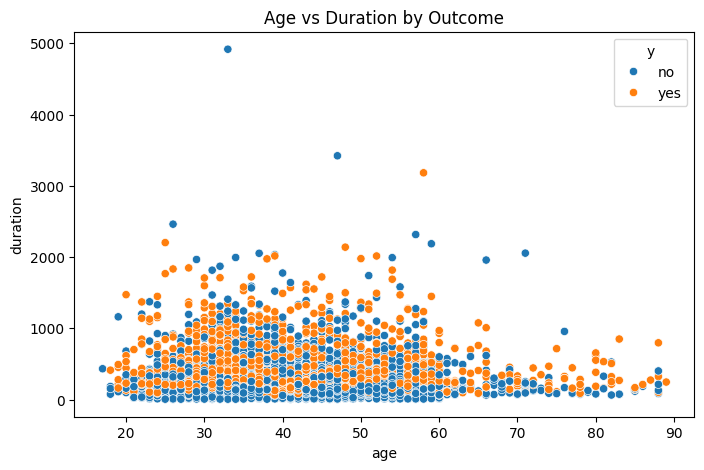

/tmp/ipykernel_2515/3538800154.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index="age_group", columns="marital", values="y_flag", aggfunc="mean")


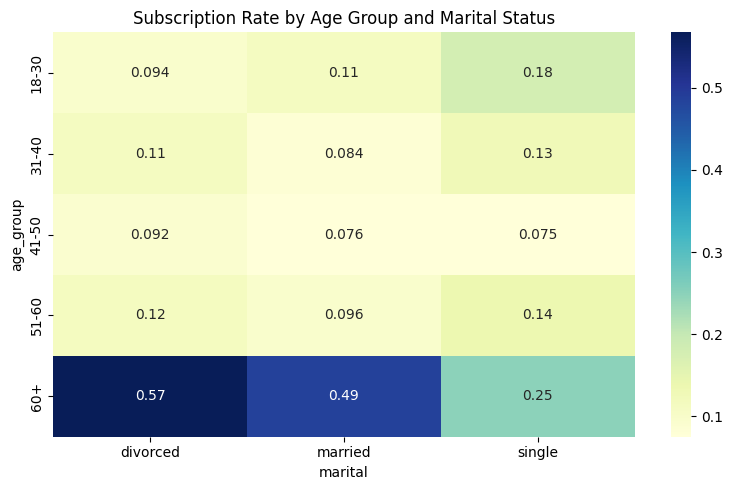

In [14]:
# 8. Multivariate analysis
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="duration", hue="y", data=df)
print("\n")
plt.title("Age vs Duration by Outcome")
plt.show()

plt.figure(figsize=(8, 5))
pivot = df.pivot_table(index="age_group", columns="marital", values="y_flag", aggfunc="mean")
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
print("\n")
plt.title("Subscription Rate by Age Group and Marital Status")
plt.tight_layout()
plt.show()

df.to_csv("bank_marketing_cleaned.csv", index=False)